This notebooks demos OST-MLE on $N=5$ with data generated from NEURON. The estimated influence matrix is valided against the ground truth connectivity matrix used to generate the raster data. See "../NEURON/NEURON_Demo.ipynb" for how this raster plot was simulated. Figure shown below compares connectivity matrix against the estimated influence matrix in both Phase 1 and Phase 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath("../scripts/"))
from helpers import *
from osmle import *

In [2]:
# Phase 1
steps1=2000
lr1=5e-3
batch_size1=1024
lambda_l1=1e-3

# Phase 2
steps2=1500
lr2=5e-3
batch_size2=1024

prefer_cuda=True
seed=123

np.random.seed(seed); torch.manual_seed(seed)
device = device_auto(prefer_cuda)

In [3]:
N=5
T=25
duration_in_s=5
h_ms = 6 # binarizing window 

### The ground truth was generated as follows, network connectivity matching that of fig2AD ###
# w_edge=0.02
# motifs = [
#     {"type": "cycle", "nodes": [0,1,2]},
#     {"type": "single_edge", "nodes": [2,3]},
#     {"type": "empty", "nodes": [4]}
# ]

# # a std of ~0.3–0.5 × mean is biologically plausible
# W_gt = generate_W_gt(N, motifs=motifs, w_mean=w_edge, w_std=0.3*w_edge, seed=42)
############### ############### ################## ################## ################ ###########

gt_path="../demo_gt_for_NEURON/5_toyexample.txt"
W_gt=getGroundTruth(gt_path)
fn="../demo_data_from_NEURON/5_toyexample/rasterplot_N5_0.txt"
numSpikes, spikeTimes = getSpikesInfo(fn)


In [4]:
_, src_fr, tar_fr = getAvgFiringRateSourceTarget(W_gt, numSpikes, duration_in_s)
print("firing rate in Hz:", tar_fr)

firing rate in Hz: 11.099999999999998


In [5]:
W_gt

array([[0.        , 0.        , 0.02216377, 0.        , 0.        ],
       [0.01839455, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.02316816, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.02216377, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [6]:
data = getDiscretizedSpikeMatrix(spikeTimes, duration_in_s, N, h_ms, binarize=True) # N times L = (duration/h)+1
paths = prepare_paths_from_spikes_2(data, T)
s_t_np, s_tp1_np = make_one_step_pairs(paths)
s_t   = torch.as_tensor(s_t_np,   dtype=torch.float32, device=device)
s_tp1 = torch.as_tensor(s_tp1_np, dtype=torch.float32, device=device)

# -------- Phase 1: dense off-diagonal mask, with L1 ----------
mask_offdiag = np.ones((N, N), dtype=np.float32); np.fill_diagonal(mask_offdiag, 0.0)
model1 = FactorizedLogisticPrior(N, mask=mask_offdiag).to(device)

_ = train_one_phase(
    model1, s_t, s_tp1,
    steps=steps1, batch_size=batch_size1, lr=lr1,
    l1_weight=lambda_l1, hard_mask_freeze=False, seed=seed+1
)

with torch.no_grad():
    beta_1 = model1.beta.detach().cpu().numpy()
    W_1_full = model1.W.detach().cpu().numpy()
    W_1 = (model1.W * model1.mask).detach().cpu().numpy()  # masked (diag=0)

# ---- Threshold to build sparse mask (absolute value) ----
# edge_mask = (np.abs(W_1) >= float(tau)).astype(np.float32)
# tau = np.mean(W_1)+np.std(W_1)
nonzero_mean = W_1[W_1 != 0].mean()
nonzero_std = W_1[W_1 != 0].std()
tau = max(0.7, nonzero_mean+(nonzero_std/2))
edge_mask = (W_1 >= float(tau)).astype(np.float32)
np.fill_diagonal(edge_mask, 0.0)
kept = int(edge_mask.sum())

# -------- Phase 2: fixed sparse mask, HARD-enforced ----------
model2 = FactorizedLogisticPrior(N, mask=edge_mask).to(device)
with torch.no_grad():
    model2.beta.copy_(torch.tensor(beta_1, dtype=torch.float32, device=device))
    # initialize W with masked W_1 (pruned entries exactly 0)
    model2.W.copy_(torch.tensor(W_1 * edge_mask, dtype=torch.float32, device=device))

_ = train_one_phase(
    model2, s_t, s_tp1,
    steps=steps2, batch_size=batch_size2, lr=lr2,
    l1_weight=0.0, hard_mask_freeze=True, seed=seed+2
)

with torch.no_grad():
    beta_2 = model2.beta.detach().cpu().numpy()
    W_2 = (model2.W * model2.mask).detach().cpu().numpy()

# ----- report (concise)
np.set_printoptions(precision=3, suppress=True)
print("\n=== SUMMARY ===")
print(f"kept edges after threshold tau={tau}: {kept} / {N*(N-1)} (~{kept/(N*(N-1)):.3f})")
# print("\nGround-truth beta:", beta_gt)
print("Phase 1     beta:", beta_1)
print("Phase 2     beta:", beta_2)
print("\nGround-truth W (cycle):\n", W_gt)
print("Phase 1     W (masked offdiag):\n", W_1)
print("Phase 2     W (sparse, fixed mask):\n", W_2)

# Quick sanity: ensure zeros exactly where mask==0
offmask_zero_violation = np.max(np.abs(W_2 * (1.0 - edge_mask)))
print(f"\nMax |W_2| outside mask (should be 0): {offmask_zero_violation:.6f}")


=== SUMMARY ===
kept edges after threshold tau=0.7: 4 / 20 (~0.200)
Phase 1     beta: [-1.526 -1.335 -1.205 -1.609 -2.05 ]
Phase 2     beta: [-1.96  -1.949 -1.529 -1.704 -2.946]

Ground-truth W (cycle):
 [[0.    0.    0.022 0.    0.   ]
 [0.018 0.    0.    0.    0.   ]
 [0.    0.023 0.    0.    0.   ]
 [0.    0.    0.022 0.    0.   ]
 [0.    0.    0.    0.    0.   ]]
Phase 1     W (masked offdiag):
 [[ 0.    -0.021  1.184  0.443 -0.031]
 [ 1.139  0.     0.187  0.13   0.302]
 [-0.063  1.487  0.     0.351  0.047]
 [-0.017  0.114  1.495  0.    -0.017]
 [ 0.103  0.223  0.384  0.225  0.   ]]
Phase 2     W (sparse, fixed mask):
 [[ 0.    -0.     1.164  0.    -0.   ]
 [ 1.149  0.     0.     0.     0.   ]
 [-0.     1.488  0.     0.     0.   ]
 [-0.     0.     1.467  0.    -0.   ]
 [ 0.     0.     0.     0.     0.   ]]

Max |W_2| outside mask (should be 0): 0.000000


In [7]:

# === SUMMARY ===
# kept edges after threshold tau=0.15: 4 / 20 (~0.200)

# Ground-truth beta: [-1. -1. -1. -1. -1.]
# Phase 1     beta: [-1.01  -1.027 -0.987 -0.982 -0.987]
# Phase 2     beta: [-1.011 -1.041 -0.981 -0.975 -1.003]

# Ground-truth W (cycle):
#  [[0.    0.    1.053 0.    0.   ]
#  [0.874 0.    0.    0.    0.   ]
#  [0.    1.1   0.    0.    0.   ]
#  [0.    0.    1.423 0.    0.   ]
#  [0.    0.    0.    0.    0.   ]]
# Phase 1     W (masked offdiag):
#  [[ 0.     0.004  1.033  0.008 -0.021]
#  [ 0.87   0.    -0.032 -0.006 -0.004]
#  [-0.017  1.111  0.     0.017  0.002]
#  [ 0.015 -0.017  1.432  0.     0.003]
#  [ 0.001  0.004  0.014 -0.005  0.   ]]
# Phase 2     W (sparse, fixed mask):
#  [[ 0.     0.     1.043  0.    -0.   ]
#  [ 0.862  0.    -0.    -0.    -0.   ]
#  [-0.     1.1    0.     0.     0.   ]
#  [ 0.    -0.     1.425  0.     0.   ]
#  [ 0.     0.     0.    -0.     0.   ]]

# Max |W_2| outside mask (should be 0): 0.000000

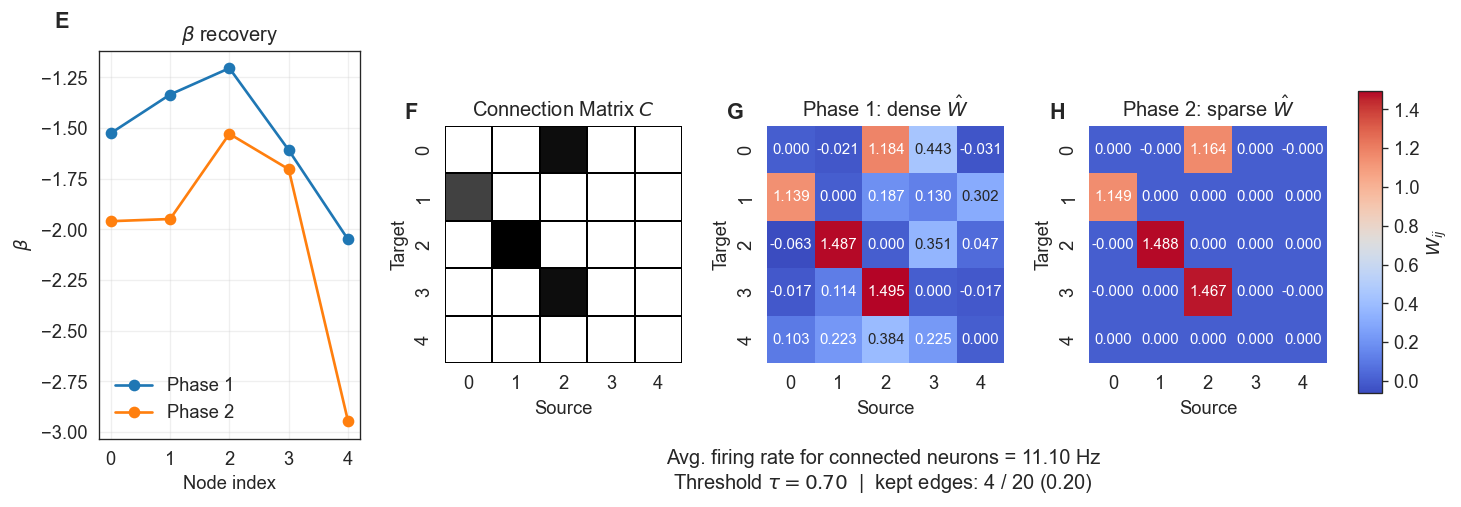

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

sns.set_style("white")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

# ----------------- Normalizations -----------------
norm_gt = Normalize(vmin=W_gt.min(), vmax=W_gt.max())
W_shared = np.concatenate([W_1.flatten(), W_2.flatten()])
norm_shared = Normalize(vmin=W_shared.min(), vmax=W_shared.max())
cmap = "coolwarm"
cmap_gt = "Greys"

# ----------------- Figure -----------------
# fig, axes = plt.subplots(1, 4, figsize=(13.2, 4.2))  # REMOVE
fig = plt.figure(figsize=(13.2, 4.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1, 1, 1, 1], wspace=0.35)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[0, 3])



# ----------------- Panel A: beta -----------------
idx = np.arange(len(beta_1))
ax0.plot(idx, beta_1, 'C0-o', label="Phase 1", lw=1.6)
ax0.plot(idx, beta_2, 'C1-o', label="Phase 2", lw=1.6)
ax0.set_xlabel("Node index")
ax0.set_ylabel(r"$\beta$")
ax0.set_title(r"$\beta$ recovery")
ax0.set_xticks(idx)
ax0.legend(frameon=False)
ax0.grid(alpha=0.3)


# ----------------- Panel B: Ground truth W -----------------
sns.heatmap(
    W_gt, ax=ax1,
    cmap=cmap_gt, norm=norm_gt,
    square=True, 
    cbar=False,
    annot=False,
    linewidths=1,      
    linecolor='black' 
)
ax1.set_title("Connection Matrix $C$")
ax1.set_xlabel("Source")
ax1.set_ylabel("Target")
ax1.set_aspect("equal")

# ----------------- Panel C: Phase 1 W -----------------
sns.heatmap(W_1, ax=ax2, cmap=cmap, norm=norm_shared, square=True, 
            cbar=False, annot=True, fmt=".3f", annot_kws={"fontsize": 9})
ax2.set_title("Phase 1: dense $\hat{W}$")
ax2.set_xlabel("Source")
ax2.set_ylabel("Target")
ax2.set_aspect("equal")  # make square

# ----------------- Panel D: Phase 2 W -----------------
sns.heatmap(W_2, ax=ax3, cmap=cmap, norm=norm_shared, square=True, 
            cbar=False, annot=True, fmt=".3f", annot_kws={"fontsize": 9})
ax3.set_title("Phase 2: sparse $\hat{W}$")
ax3.set_xlabel("Source")
ax3.set_ylabel("Target")
ax3.set_aspect("equal")  # square

# Shared colorbar with fixed size and position
cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])  
sm_shared = ScalarMappable(norm=norm_shared, cmap=cmap)
sm_shared.set_array([])
fig.colorbar(sm_shared, cax=cax, label=r"$W_{ij}$")


# ----------------- Panel labels -----------------
panel_labels = ["E", "F", "G", "H"]
axes_list = [ax0, ax1, ax2, ax3]

for label, ax in zip(panel_labels, axes_list):
    ax.text(
        -0.17, 1.1, 
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top"
    )


# ----------------- Annotation near matrices -----------------
total_edges = N * (N - 1)
fig.text(
    0.62, 0.01,   # centered under matrix panels
    rf"Threshold $\tau={tau:.2f}$  |  kept edges: {kept} / {total_edges} "
    rf"({kept/total_edges:.2f})",
    ha="center",
    fontsize=12
)
fig.text(
    0.62, 0.06,   # centered under matrix panels
    rf"Avg. firing rate for connected neurons = {tar_fr:.2f} Hz",
    ha="center",
    fontsize=12
)


plt.show()